In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
from sklearn.model_selection import KFold, cross_validate, train_test_split
from xgboost.callback import EarlyStopping
import seaborn as sb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
def read_data(file_path:str) -> pd.DataFrame:
    # Carregar os dados
    try:
        # Tente carregar do seu ambiente local
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print("Arquivo não encontrado. Certifique-se de que estão no diretório correto.")
        print(f"Diretorio do arquivo mandado {file_path}")
        print(f"Diretorio atual {os.getcwd()}")
    # Visualizar as primeiras linhas do conjunto de treino
    if not df.empty:
        print("Amostra do Conjunto")
        print(df.head())

    return df

df = read_data("../house-prices-data/train.csv")

Amostra do Conjunto
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0

In [3]:
def clean_and_impute_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Função para limpar e imputar valores ausentes em um DataFrame de dados imobiliários.

    A função aplica as seguintes estratégias:
    - Preenche com 'NA' para características categóricas onde a ausência é significativa (ex: 'Alley', 'BsmtQual').
    - Preenche com 'None' ou 0 para características de alvenaria ('MasVnrType', 'MasVnrArea').
    - Preenche 'LotFrontage' com a mediana do bairro ('Neighborhood').
    - Preenche 'GarageYrBlt' com 0, pois a ausência indica que não há garagem.
    - Preenche o valor ausente em 'Electrical' com o valor mais frequente (moda).

    Args:
        df: DataFrame original com valores ausentes.

    Returns:
        DataFrame com os valores ausentes tratados.
    """
    df_copy = df.copy()

    print("\n=== LIMPEZA E IMPUTAÇÃO DE DADOS ===")
    # --- 1. Categóricos onde NaN significa 'Não Possui' ---
    # Lista completa de colunas para preencher com 'NA'
    cols_fill_na = [
        'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
        'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
        'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature'
    ]
    for col in cols_fill_na:
        df_copy[col] = df_copy[col].fillna('NA')

    # --- 2. Lógica Sofisticada para 'GarageYrBlt' ---
    # Primeiro, identificamos as casas que não têm garagem (após a etapa anterior)
    mask_no_garage = df_copy["GarageType"] == "NA"
    
    # Para casas SEM garagem, preenchemos NaN em 'GarageYrBlt' com 0
    df_copy.loc[mask_no_garage, "GarageYrBlt"] = df_copy.loc[mask_no_garage, "GarageYrBlt"].fillna(0)
    
    # Para casas COM garagem, preenchemos NaN em 'GarageYrBlt' com o ano de construção da casa
    df_copy.loc[~mask_no_garage, "GarageYrBlt"] = df_copy.loc[~mask_no_garage, "GarageYrBlt"].fillna(
        df_copy.loc[~mask_no_garage, "YearBuilt"]
    )

    # --- 3. Lógica Espacial para 'LotFrontage' ---
    # Usa a mediana do bairro para manter a coerência
    df_copy['LotFrontage'] = df_copy.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

    # --- 4. Lógica para Alvenaria ---
    # Se o tipo é ausente, preenche com 'NA' e a área com 0
    df_copy['MasVnrType'] = df_copy['MasVnrType'].fillna('NA')
    df_copy['MasVnrArea'] = df_copy['MasVnrArea'].fillna(0)

    # --- 5. Imputação por Moda para 'Electrical' ---
    # Preenche o único valor ausente com o mais comum
    electrical_mode = df_copy['Electrical'].mode()[0]
    df_copy['Electrical'] = df_copy['Electrical'].fillna(electrical_mode)

    remaining_missing = df_copy.isnull().sum().sum()
    if remaining_missing == 0:
        print("Todos os valores ausentes foram tratados com sucesso!")
    else:
        print(f"Ainda restam {remaining_missing} valores ausentes.")

    return df_copy

df = clean_and_impute_data(df)


=== LIMPEZA E IMPUTAÇÃO DE DADOS ===
Todos os valores ausentes foram tratados com sucesso!


In [4]:
def preparar_dados_para_xgboost(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepara um DataFrame para treinamento com XGBoost, tratando colunas
    ordinais e nominais conforme especificado.

    Args:
        df: O DataFrame contendo os dados brutos.

    Returns:
        O DataFrame processado e pronto para o XGBoost.
    """
    # Copia o DataFrame para evitar modificações no original
    df_proc = df.copy()

    print("\n=== PRÉ-PROCESSAMENTO PARA XGBOOST ===")
    # 1. DEFINIÇÃO DAS COLUNAS
    
    # Colunas Categóricas Nominais (serão convertidas para o tipo 'category')
    nominais = [
        'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig', 
        'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 
        'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 
        'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 
        'MiscFeature', 'SaleType', 'SaleCondition'
    ]

    # Colunas Categóricas Ordinais e seus respectivos mapeamentos
    ordinais_mapeamento = {
        'LotShape': {'Reg': 3, 'IR1': 2, 'IR2': 1, 'IR3': 0},
        'Utilities': {'AllPub': 3, 'NoSewr': 2, 'NoSeWa': 1, 'ELO': 0},
        'LandSlope': {'Gtl': 2, 'Mod': 1, 'Sev': 0},
        'OverallQual': {i: i for i in range(1, 11)},
        'OverallCond': {i: i for i in range(1, 11)},
        'ExterQual': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0},
        'ExterCond': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0},
        'BsmtQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0},
        'BsmtCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0},
        'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NA': 0},
        'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0},
        'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0},
        'HeatingQC': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0},
        'KitchenQual': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0},
        'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0},
        'FireplaceQu': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0},
        'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'NA': 0},
        'GarageQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0},
        'GarageCond': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0},
        'PavedDrive': {'Y': 2, 'P': 1, 'N': 0},
        'PoolQC': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'NA': 0},
        'Fence': {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NA': 0}
    }

    # 2. TRATAMENTO DAS ORDINAIS
    print("Mapeando colunas ordinais...")
    for col, mapping in ordinais_mapeamento.items():
        if col in df_proc.columns:
            df_proc[col] = df_proc[col].map(mapping)
        else:
            print(f"Aviso: Coluna ordinal '{col}' não encontrada no DataFrame.")
            
    # 3. TRATAMENTO DAS NOMINAIS
    print("Convertendo colunas nominais para o tipo 'category'...")
    for col in nominais:
        if col in df_proc.columns:
            # A coluna MSSubClass é numérica mas representa uma categoria
            df_proc[col] = df_proc[col].astype('category')
        else:
            print(f"Aviso: Coluna nominal '{col}' não encontrada no DataFrame.")
            
    print("\nPré-processamento concluído.")
    return df_proc

df_xgb = preparar_dados_para_xgboost(df)


=== PRÉ-PROCESSAMENTO PARA XGBOOST ===
Mapeando colunas ordinais...
Convertendo colunas nominais para o tipo 'category'...

Pré-processamento concluído.


Resultados da Avaliação com Validação Cruzada (10 folds) - Alvo em Escala de Log:
----------------------------------------------------------------------
R² (R-squared):                   0.9019 (+/- 0.0263)
RMSE (Root Mean Squared Error):   0.1231 (+/- 0.0192)
MAE (Mean Absolute Error):        0.0834 (+/- 0.0100)
----------------------------------------------------------------------

Modelo final treinado com 1985 árvores (early stopping).

Resultados da Avaliação do Modelo Final no Conjunto de Validação:
----------------------------------------------------------------------
Métricas na Escala de Log:
R² (R-squared):                   0.9371
RMSE (Root Mean Squared Error):   0.1110
MAE (Mean Absolute Error):        0.0730

Métricas na Escala Original de Preço ($):
RMSE (Root Mean Squared Error):   $27,888.44
MAE (Mean Absolute Error):        $14,059.56
----------------------------------------------------------------------
(Isso significa que, em média, as previsões de preço do modelo f

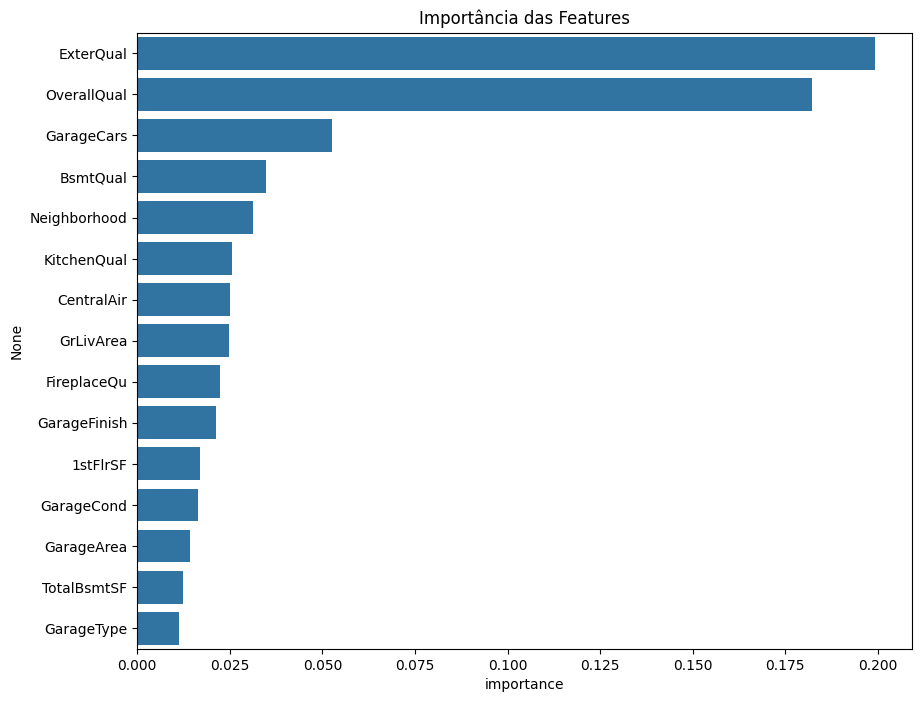

In [5]:
def treinar_e_avaliar_xgboost(df: pd.DataFrame):
    """
    Remove a coluna 'Id', treina um modelo XGBoost para prever 'SalePrice'
    e o avalia usando validação cruzada com 10 folds.

    Args:
        df (pd.DataFrame): O DataFrame contendo os dados de casas.

    Returns:
        xgb.XGBRegressor: O modelo XGBoost treinado.
    """
    # 1. Preparar os dados
    # Remover a coluna 'Id'
    df = df.drop('Id', axis=1)
    # Separar as features (X) e o alvo (y)
    X = df.drop('SalePrice', axis=1)
    y = df['SalePrice']
    # Análise e Transformação da variável alvo 'SalePrice'
    # Aplicar log1p (log(1+x)) para normalizar a distribuição
    y_log = np.log1p(y)
    # Garantir que as colunas categóricas estão no formato correto para o XGBoost
    for col in X.select_dtypes(include=['object', 'category']).columns:
        X[col] = X[col].astype('category')

    # 2. Criar um modelo APENAS para a validação cruzada (sem callbacks)
    modelo_para_cv = xgb.XGBRegressor(
        objective='reg:squarederror',
        enable_categorical=True,
        tree_method='hist',
        random_state=42,
        eval_metric='rmse',
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.8,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.005
    )

    # 3. Usar validação cruzada com 10 folds
    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    # 4. Avaliar o modelo usando R², RMSE e MAE
    # Como a variável alvo foi transformada, as métricas de erro (RMSE, MAE)
    # serão na escala de log. O R² não é afetado da mesma forma.
    scoring = {
        'r2': 'r2',
        'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
        'neg_mean_absolute_error': 'neg_mean_absolute_error'
    }

    # Executar a validação cruzada
    scores = cross_validate(modelo_para_cv, X, y_log, cv=kf, scoring=scoring, n_jobs=-1)

    # Calcular as médias e desvios padrão das métricas
    mean_r2 = np.mean(scores['test_r2'])
    std_r2 = np.std(scores['test_r2'])
    mean_rmse_log = -np.mean(scores['test_neg_root_mean_squared_error'])
    std_rmse_log = np.std(scores['test_neg_root_mean_squared_error'])
    mean_mae_log = -np.mean(scores['test_neg_mean_absolute_error'])
    std_mae_log = np.std(scores['test_neg_mean_absolute_error'])

    # Exibir os resultados (erros na escala de log)
    print("Resultados da Avaliação com Validação Cruzada (10 folds) - Alvo em Escala de Log:")
    print("-" * 70)
    print(f"R² (R-squared):                   {mean_r2:.4f} (+/- {std_r2:.4f})")
    print(f"RMSE (Root Mean Squared Error):   {mean_rmse_log:.4f} (+/- {std_rmse_log:.4f})")
    print(f"MAE (Mean Absolute Error):        {mean_mae_log:.4f} (+/- {std_mae_log:.4f})")
    print("-" * 70)

    # 5. AGORA, criar o modelo final com os callbacks para o treinamento
    modelo_xgb = xgb.XGBRegressor(
        objective='reg:squarederror',
        enable_categorical=True,
        tree_method='hist',
        random_state=42,
        eval_metric='rmse',
        callbacks=[EarlyStopping(rounds=50, save_best=True)], # CALLBACKS APLICADOS AQUI
        n_estimators=2000,
        learning_rate=0.01,
        max_depth=5,
        subsample=0.7,
        colsample_bytree=0.8,
        min_child_weight=1,
        gamma=0.1,
        reg_alpha=0.005
    )

    # 5. Treinar o modelo final com todos os dados
    # Para usar early stopping, precisamos de um conjunto de validação
    X_train, X_val, y_train_log, y_val_log = train_test_split(X, y_log, test_size=0.1, random_state=42)

    modelo_xgb.fit(
        X_train, y_train_log,
        eval_set=[(X_val, y_val_log)],
        verbose=False
    )

    print(f"\nModelo final treinado com {modelo_xgb.best_iteration} árvores (early stopping).")


    print("\nResultados da Avaliação do Modelo Final no Conjunto de Validação:")
    print("-" * 70)

    # Fazer previsões no conjunto de validação
    predicoes_val = modelo_xgb.predict(X_val)

    # Calcular métricas na escala de log (como o modelo foi treinado)
    r2_val = r2_score(y_val_log, predicoes_val)
    rmse_val_log = np.sqrt(mean_squared_error(y_val_log, predicoes_val))
    mae_val_log = mean_absolute_error(y_val_log, predicoes_val)

    print("Métricas na Escala de Log:")
    print(f"R² (R-squared):                   {r2_val:.4f}")
    print(f"RMSE (Root Mean Squared Error):   {rmse_val_log:.4f}")
    print(f"MAE (Mean Absolute Error):        {mae_val_log:.4f}")

    # Reverter a transformação log para métricas na escala original (mais interpretável)
    y_val_original = np.expm1(y_val_log)
    predicoes_val_original = np.expm1(predicoes_val)

    rmse_val_original = np.sqrt(mean_squared_error(y_val_original, predicoes_val_original))
    mae_val_original = mean_absolute_error(y_val_original, predicoes_val_original)
    
    print("\nMétricas na Escala Original de Preço ($):")
    print(f"RMSE (Root Mean Squared Error):   ${rmse_val_original:,.2f}")
    print(f"MAE (Mean Absolute Error):        ${mae_val_original:,.2f}")
    print("-" * 70)
    print(f"(Isso significa que, em média, as previsões de preço do modelo final erram por aproximadamente ${mae_val_original:,.2f})")


    # Extrair e plotar a importância das features
    feature_importances = pd.DataFrame(
        modelo_xgb.feature_importances_,
        index=X.columns,
        columns=['importance']
    ).sort_values('importance', ascending=False)

    # Plotar as 15 features mais importantes
    plt.figure(figsize=(10, 8))
    sb.barplot(x=feature_importances.head(15).importance, y=feature_importances.head(15).index)
    plt.title('Importância das Features')
    plt.show()

    return modelo_xgb

modelo_xgb = treinar_e_avaliar_xgboost(df_xgb)

In [6]:
df_test = read_data("../house-prices-data/test.csv")
df_test = clean_and_impute_data(df_test)
df_test_xgb = preparar_dados_para_xgboost(df_test)

Amostra do Conjunto
     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462          20       RL         81.0    14267   Pave   NaN      IR1   
2  1463          60       RL         74.0    13830   Pave   NaN      IR1   
3  1464          60       RL         78.0     9978   Pave   NaN      IR1   
4  1465         120       RL         43.0     5005   Pave   NaN      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence MiscFeature  \
0         Lvl    AllPub  ...         120        0    NaN  MnPrv         NaN   
1         Lvl    AllPub  ...           0        0    NaN    NaN        Gar2   
2         Lvl    AllPub  ...           0        0    NaN  MnPrv         NaN   
3         Lvl    AllPub  ...           0        0    NaN    NaN         NaN   
4         HLS    AllPub  ...         144        0    NaN    NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleConditio

In [7]:
def gerar_submissao_kaggle(modelo_treinado: xgb.XGBRegressor, df_teste: pd.DataFrame):
    """
    Usa um modelo XGBoost treinado para fazer previsões em um conjunto de teste,
    formata os resultados e os salva em um arquivo CSV para submissão no Kaggle.

    A função assume que o modelo foi treinado em um alvo transformado por np.log1p()
    e reverte essa transformação para a submissão final.

    Args:
        modelo_treinado (xgb.XGBRegressor): O modelo XGBoost já treinado.
        df_teste (pd.DataFrame): O DataFrame de teste, que não contém a coluna 'SalePrice'.
    """
    # 1. Fazer uma cópia para evitar alterar o DataFrame original
    df_teste_proc = df_teste.copy()

    # 2. Salvar a coluna 'Id' para o arquivo final e preparar o X_teste
    ids_teste = df_teste_proc['Id']
    X_teste = df_teste_proc.drop('Id', axis=1)

    # 3. Garantir que as colunas categóricas do teste tenham o mesmo tipo que no treino
    # Isso é CRUCIAL para que o XGBoost com 'enable_categorical=True' funcione corretamente.
    print("Preparando dados de teste...")
    for col in X_teste.select_dtypes(include=['object', 'category']).columns:
        X_teste[col] = X_teste[col].astype('category')

    # 4. Fazer as previsões (elas sairão na escala de log, pois o modelo foi treinado assim)
    print("Gerando previsões...")
    previsoes_log = modelo_treinado.predict(X_teste)

    # 5. Reverter a transformação logarítmica para obter o preço real
    # O modelo previu log(1+SalePrice), então usamos exp(x) - 1 para reverter.
    previsoes_preco_final = np.expm1(previsoes_log)
    
    # Garantir que não há previsões negativas (um efeito colateral raro, mas possível)
    previsoes_preco_final[previsoes_preco_final < 0] = 0

    # 6. Criar o DataFrame de submissão no formato exigido
    df_submissao = pd.DataFrame({
        'Id': ids_teste,
        'SalePrice': previsoes_preco_final
    })

    # 7. Salvar o DataFrame em um arquivo .csv
    nome_arquivo = 'submission.csv'
    df_submissao.to_csv(nome_arquivo, index=False)

    print("-" * 50)
    print(f"Arquivo de submissão '{nome_arquivo}' criado com sucesso!")
    print(f"O arquivo contém {len(df_submissao)} previsões.")
    print("\nExemplo das primeiras 5 linhas do arquivo gerado:")
    print(df_submissao.head())
    print("-" * 50)

gerar_submissao_kaggle(modelo_xgb, df_test_xgb)

Preparando dados de teste...
Gerando previsões...
--------------------------------------------------
Arquivo de submissão 'submission.csv' criado com sucesso!
O arquivo contém 1459 previsões.

Exemplo das primeiras 5 linhas do arquivo gerado:
     Id      SalePrice
0  1461  125938.265625
1  1462  154666.031250
2  1463  189701.906250
3  1464  187524.531250
4  1465  193530.734375
--------------------------------------------------
